# BPT diagram
To separate these different classes of galaxies on a BPT diagram plotting **[O III]$\lambda5007$/H$\beta$** versus **[N II]$\lambda6583$/H$\alpha$**, you can use a combination of theoretical and empirical demarcation lines. 

For the formulas below, let:
*   $y = \log([\text{O III}] / \text{H}\beta)$
*   $x = \log([\text{N II}] / \text{H}\alpha)$

**1. Pure Star-Forming Galaxies**
Galaxies powered purely by star formation fall below the empirical boundary defined by Kauffmann et al. (2003).
**Formula:** $y < \frac{0.61}{x - 0.05} + 1.30$

**2. Composite (Transition) Galaxies**
These objects have spectra indicating a blend of star formation and AGN activity. They fall between the Kauffmann (2003) empirical line and the theoretical maximum starburst line defined by Kewley et al. (2001).
**Formula:** $\frac{0.61}{x - 0.05} + 1.30 < y < \frac{0.61}{x - 0.47} + 1.19$

**3. Active Galactic Nuclei (AGN)**
Galaxies that are entirely dominated by an AGN (which includes both Seyferts and LINERs) fall above the Kewley (2001) theoretical maximum starburst line. These objects cannot be explained by any combination of star formation parameters.
**Formula:** $y > \frac{0.61}{x - 0.47} + 1.19$

**4. Separating Seyferts from LINERs**
Within the AGN regime (above the Kewley 2001 line), objects are further split based on their ionization state. While the [S II] and [O I] diagrams are often preferred for this separation, an empirical dividing line specific to the [N II]/H$\alpha$ diagram was defined by Schawinski et al. (2007).
**Demarcation Line Formula:** $y = 1.05x + 0.45$
*   **Seyfert galaxies** have higher ionization ratios and fall **above** this line ($y > 1.05x + 0.45$).
*   **LINER galaxies** have lower ionization ratios and fall **below** this line ($y < 1.05x + 0.45$).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sdss.metadata import MetaData

meta = MetaData()
pd.set_option("display.max_columns", None)

# Custom functions

## BPT boundaries

In [2]:
def bpt_boundary_lines():
    # Kauffmann et al. (2003) - Empirical Star-Forming line
    x_kauff = np.linspace(-2.0, 0.0, 1000)
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    # Kewley et al. (2001) - Theoretical Maximum Starburst line
    x_kewley = np.linspace(-2.0, 0.4, 1000)
    y_kewley = 0.61 / (x_kewley - 0.47) + 1.19

    # Schawinski et al. (2007) - Seyfert / LINER division
    x_schaw = np.linspace(-0.18, 1.5, 1000)
    y_schaw = 1.05 * x_schaw + 0.45

    return (x_kauff, y_kauff), (x_kewley, y_kewley), (x_schaw, y_schaw)

# Config

## Constants

In [4]:
se_cols = ["mse", "mse_filter_250", "mse_97", "mse_filter_250_97"]
se_rank_cols = [f"rank_{col}" for col in se_cols]
# ----------------------------------------------
rse_cols = [f"{col}_rel" for col in se_cols]
rse_rank_cols = [f"rank_{col}_rel" for col in se_cols]
# ----------------------------------------------
se_family = ["mse", "mse_97", "mse_filter_250", "mse_filter_250_97"]
rse_family = [f"{col}_rel" for col in se_family]

In [5]:
cols_ratios = [
    "balmer_decrement",
    "nii_to_halpha",
    "oiii_to_hbeta",
    "oiii_to_oii",
    "o3n2_index",
    "sii_to_halpha",
    "sii_density_ratio",
]

## Directories

In [6]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
ch_4_dir = f"{thesis_dir}/chapters/04_figures"

# Data

In [7]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

# lines_df = pd.read_csv(
#     f"{spectra_dir}/meta_data/lines_EdgarOrtiz.csv",
#     index_col="specObjID",
# )

# meta_with_lines_df = pd.read_csv(
#     f"{spectra_dir}/final_spec_n_z_warning_drop_with_lines.csv.gz",
#     index_col="specobjid",
# )

In [8]:
meta_with_ratios_df.head(3)
# final_meta_df.head(3)

,mjd,plate,fiberid,run2d,ra,dec,z,zErr,zWarning,class,subClass,z_noqso,zErr_noqso,zWarning_noqso,targetType,programname,instrument,snMedian,ABSSB,BROAD,ebv,indexArray,oii_3726_flux,oii_3729_flux,h_beta_flux,oiii_4959_flux,oiii_5007_flux,oiii_flux,h_alpha_flux,nii_6548_flux,nii_6584_flux,sii_6717_flux,sii_6731_flux,oii_3726_flux_err,oii_3729_flux_err,h_beta_flux_err,oiii_4959_flux_err,oiii_5007_flux_err,oiii_flux_err,h_alpha_flux_err,nii_6548_flux_err,nii_6584_flux_err,sii_6717_flux_err,sii_6731_flux_err,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,o3n2_index,sii_to_halpha,sii_density_ratio
specobjid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1874756710606858240,52976,1665,485,26,49.861444,41.540485,0.017909,0.000004,0,GALAXY,BROADLINE,0,0,0,SCIENCE,perseus,SDSS,94.13022,BROADLINE,BROADLINE,0.138756,2.0,NaN,30418890.00,109.63340,NaN,176.81650,174.70850,109.7575,49.30014,148.70060,3.150983,NaN,-7.832294e-01,1.842604e+06,17.43791,19.09110,17.88523,21.45677,35.74986,11.300770,34.08569,31.61602,31.82735,1.001132,1.354810,1.612798,NaN,0.075701,NaN,NaN
1874765781577787392,52976,1665,518,26,49.918970,41.548643,0.021434,0.000004,0,GALAXY,BROADLINE,0,0,0,SCIENCE,perseus,SDSS,92.63803,BROADLINE,BROADLINE,0.141073,3.0,NaN,30924.64,41.71867,2.058654,72.43165,67.69716,132.8577,29.28021,88.31586,NaN,18.97761,1.139662e+06,3.962919e+04,14.98429,12.20163,12.41198,12.80094,23.17760,6.114465,18.44262,16.03369,16.29948,3.184610,0.664740,1.736193,NaN,0.416946,NaN,NaN
1874776226938251264,52976,1665,556,26,50.251707,41.562451,0.015699,0.000006,0,GALAXY,BROADLINE,0,0,0,SCIENCE,perseus,SDSS,90.91905,BROADLINE,BROADLINE,0.142785,5.0,NaN,NaN,169.26810,NaN,147.23940,150.70450,261.2984,45.43762,137.05040,27.470890,NaN,-7.819291e-01,-7.819291e-01,14.49883,15.25546,15.11998,14.26691,25.16728,7.907939,23.85214,23.79437,23.95586,1.543695,0.524498,0.869859,NaN,0.219705,NaN,NaN


# Scores

## SE + RSE scores

In [9]:
bin_id = "bin_03"
res_scores_03_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    usecols=["specobjid"] + se_cols + rse_cols,
    index_col="specobjid",
)

rank = np.arange(res_scores_03_df.shape[0]) + 1
res_03_scores_rank_df = res_scores_03_df.copy()
# score_rank_df
for col in res_scores_03_df.columns:

    index_sorted = res_scores_03_df.sort_values(by=col, ascending=False).index

    res_03_scores_rank_df.loc[index_sorted, f"rank_{col}"] = rank
    res_03_scores_rank_df[f"rank_{col}"].astype(int)

n_spec = res_scores_03_df.shape[0]
n_top_1_pct = int(n_spec * 0.01)
n_top_1_pct, n_spec

(1818, 181850)

In [10]:
res_03_scores_rank_df.head()

,mse_rel,mse_filter_250_97_rel,mse_97_rel,mse,mse_97,mse_filter_250_97,mse_filter_250,mse_filter_250_rel,rank_mse_rel,rank_mse_filter_250_97_rel,rank_mse_97_rel,rank_mse,rank_mse_97,rank_mse_filter_250_97,rank_mse_filter_250,rank_mse_filter_250_rel
specobjid,,,,,,,,,,,,,,,,
1437819582281705472,3.549991,2.582845,2.660625,3.570211,2.631072,2.548220,3.305904,3.388511,13249.0,21423.0,20366.0,8755.0,10313.0,10084.0,7623.0,15236.0
1792473383787587584,3.592197,2.827291,2.874075,3.230481,2.715585,2.662638,3.150359,3.490994,11806.0,6400.0,7507.0,16243.0,7376.0,6116.0,11194.0,11277.0
1566270578824865792,3.799695,2.967733,3.016445,3.215022,2.564632,2.517923,3.124369,3.686568,6946.0,3265.0,3952.0,16789.0,13498.0,11560.0,11972.0,6498.0
1833056640966879232,3.418285,2.751345,2.802071,2.965650,2.507619,2.460364,2.933262,3.354621,18889.0,9324.0,10444.0,28087.0,16967.0,14928.0,20074.0,16849.0
2824940385879484416,3.393606,2.592578,2.649388,2.839407,2.384083,2.344867,2.787019,3.352981,20228.0,20498.0,21431.0,36848.0,27263.0,24506.0,29881.0,16922.0


# Residual scores

# Latent space

In [11]:
# load data
load_from_dir = "/home/elom/gdrive/career/portfolio/phd/code/latent/bin_03"

common_latent_arr = np.load(
    f"{load_from_dir}/common_ids_bin_03_lof_iforest.npy"
).astype(int)
iforest_distinct_arr = np.load(
    f"{load_from_dir}/distinct_ids_iforest_bin_03.npy"
).astype(int)
lof_distinct_arr = np.load(f"{load_from_dir}/distinct_ids_lof_bin_03.npy").astype(int)

common_ratios_df = meta_with_ratios_df.loc[common_latent_arr, cols_ratios]
iforest_ratios_df = meta_with_ratios_df.loc[iforest_distinct_arr, cols_ratios]
lof_ratios_df = meta_with_ratios_df.loc[lof_distinct_arr, cols_ratios]


n2_ha_common = common_ratios_df["nii_to_halpha"].values
o3_hb_common = common_ratios_df["oiii_to_hbeta"].values
log_n2_ha_common = np.log10(n2_ha_common)
log_o3_hb_common = np.log10(o3_hb_common)

n2_ha_iforest = iforest_ratios_df["nii_to_halpha"].values
o3_hb_iforest = iforest_ratios_df["oiii_to_hbeta"].values
log_n2_ha_iforest = np.log10(n2_ha_iforest)
log_o3_hb_iforest = np.log10(o3_hb_iforest)

n2_ha_lof = lof_ratios_df["nii_to_halpha"].values
o3_hb_lof = lof_ratios_df["oiii_to_hbeta"].values
log_n2_ha_lof = np.log10(n2_ha_lof)
log_o3_hb_lof = np.log10(o3_hb_lof)

In [12]:
common_latent_arr.shape

(518,)

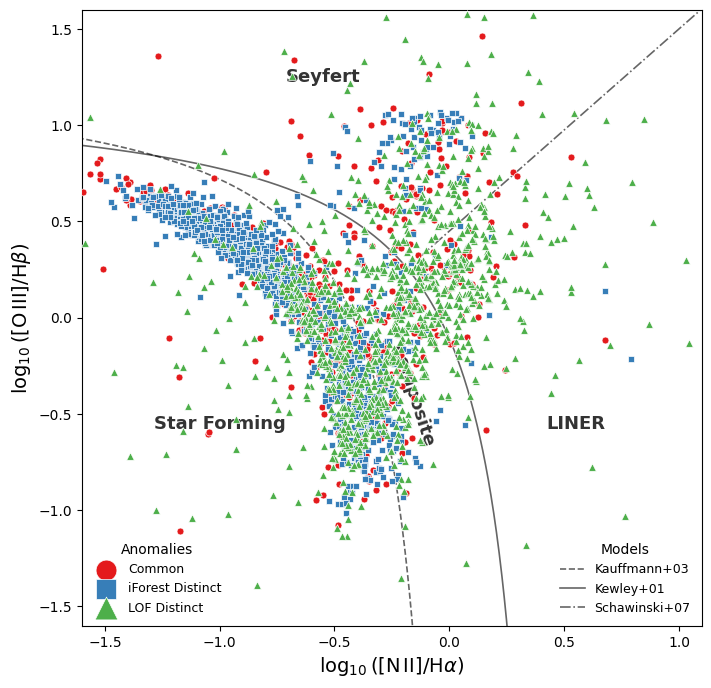

In [13]:
(x_kauff, y_kauff), (x_kewley, y_kewley), (x_schaw, y_schaw) = bpt_boundary_lines()

fig, ax = plt.subplots(figsize=(8, 8))
# -------------------------------------------------------------
# Boundaries
line_params = {"color": "black", "lw": 1.2, "alpha": 0.6, "zorder": 1}
(line_kauff,) = ax.plot(x_kauff, y_kauff, "--", **line_params, label="Kauffmann+03")
(line_kewley,) = ax.plot(x_kewley, y_kewley, "-", **line_params, label="Kewley+01")
(line_schaw,) = ax.plot(x_schaw, y_schaw, "-.", **line_params, label="Schawinski+07")

# (line_kauff,) = ax.plot(
#     x_kauff, y_kauff, "k--", lw=1.5, alpha=0.8, zorder=1, label="Kauffmann+03"
# )
# (line_kewley,) = ax.plot(
#     x_kewley, y_kewley, "k-", lw=1.5, alpha=0.8, zorder=1, label="Kewley+01"
# )
# (line_schaw,) = ax.plot(
#     x_schaw, y_schaw, "k-.", lw=1.5, alpha=0.8, zorder=1, label="Schawinski+07"
# )
# We use 'zorder=5' to make sure these sit on the very top layer
scatter_common = ax.scatter(
    log_n2_ha_common,
    log_o3_hb_common,
    color="#e41a1c",
    marker="o",
    s=25,
    edgecolors="white",
    linewidths=0.5,
    zorder=5,
    label="Common",
)
scatter_iforest = ax.scatter(
    log_n2_ha_iforest,
    log_o3_hb_iforest,
    color="#377eb8",
    marker="s",
    s=25,
    edgecolors="white",
    linewidths=0.5,
    zorder=5,
    label="iForest Distinct",
)
scatter_lof = ax.scatter(
    log_n2_ha_lof,
    log_o3_hb_lof,
    color="#4daf4a",
    marker="^",
    s=30,
    edgecolors="white",
    linewidths=0.5,
    zorder=5,
    label="LOF Distinct",
)

text_style = {"fontsize": 13, "fontweight": "bold", "va": "center", "alpha": 0.8}
ax.text(-1.0, -0.55, "Star Forming", ha="center", **text_style)
ax.text(-0.16, -0.4, "Composite", ha="center", rotation=-72, **text_style)
ax.text(-0.55, 1.25, "Seyfert", ha="center", **text_style)
ax.text(0.55, -0.55, "LINER", ha="center", **text_style)
# # -------------------------------------------------------------
# # common anomalies
# # params = {"s": 6, "alpha": 0.75, "edgecolors": "none", "zorder": 1}
# # -------------------------------------------------------------
# scatter_common = ax.scatter(
#     log_n2_ha_common,
#     log_o3_hb_common,
#     marker="o",
#     color="#e41a1c",
#     **params,
#     label="Common"
# )
# # -------------------------------------------------------------
# # iforest distinct anomalies
# # -------------------------------------------------------------
# scatter_iforest = ax.scatter(
#     log_n2_ha_iforest,
#     log_o3_hb_iforest,
#     marker="^",
#     color="#377eb8",
#     **params,
#     label="iForest"
# )
# # # -------------------------------------------------------------
# # # lof distinct anomalies
# # # -------------------------------------------------------------
# scatter_lof = ax.scatter(
#     log_n2_ha_lof, log_o3_hb_lof, marker="s", color="#4daf4a", **params, label="LOF"
# )
# -------------------------------------------------------------
# Add region text labels
# label_style = {"fontsize": 12, "fontweight": "bold", "ha": "center", "alpha": 1}
# ax.text(-1.05, -0.6, "STAR FORMING", **label_style)
# ax.text(-0.18, -0.45, "COMPOSITE", **label_style, rotation=-68)
# ax.text(-0.55, 1.25, "SEYFERT", **label_style)
# ax.text(0.55, -0.6, "LINER", **label_style)

# Set axis limits and labels
ax.set_xlim([-1.6, 1.1])
ax.set_ylim([-1.6, 1.6])
# ax.set_xlim([-2, 2])
# ax.set_ylim([-2, 2])
ax.set_xlabel(r"$\log_{10}([\mathrm{N\,II}] / \mathrm{H}\alpha)$", fontsize=14)
ax.set_ylabel(r"$\log_{10}([\mathrm{O\,III}] / \mathrm{H}\beta)$", fontsize=14)

# -------------------------------------------------------------
# Line legends
line_legend = ax.legend(
    handles=[line_kauff, line_kewley, line_schaw],
    loc="lower right",
    fontsize=9,
    frameon=False,
    title="Models",
)

ax.add_artist(line_legend)

ax.legend(
    handles=[scatter_common, scatter_iforest, scatter_lof],
    loc="lower left",
    fontsize=9,
    frameon=False,
    title="Anomalies",
    markerscale=3,
)

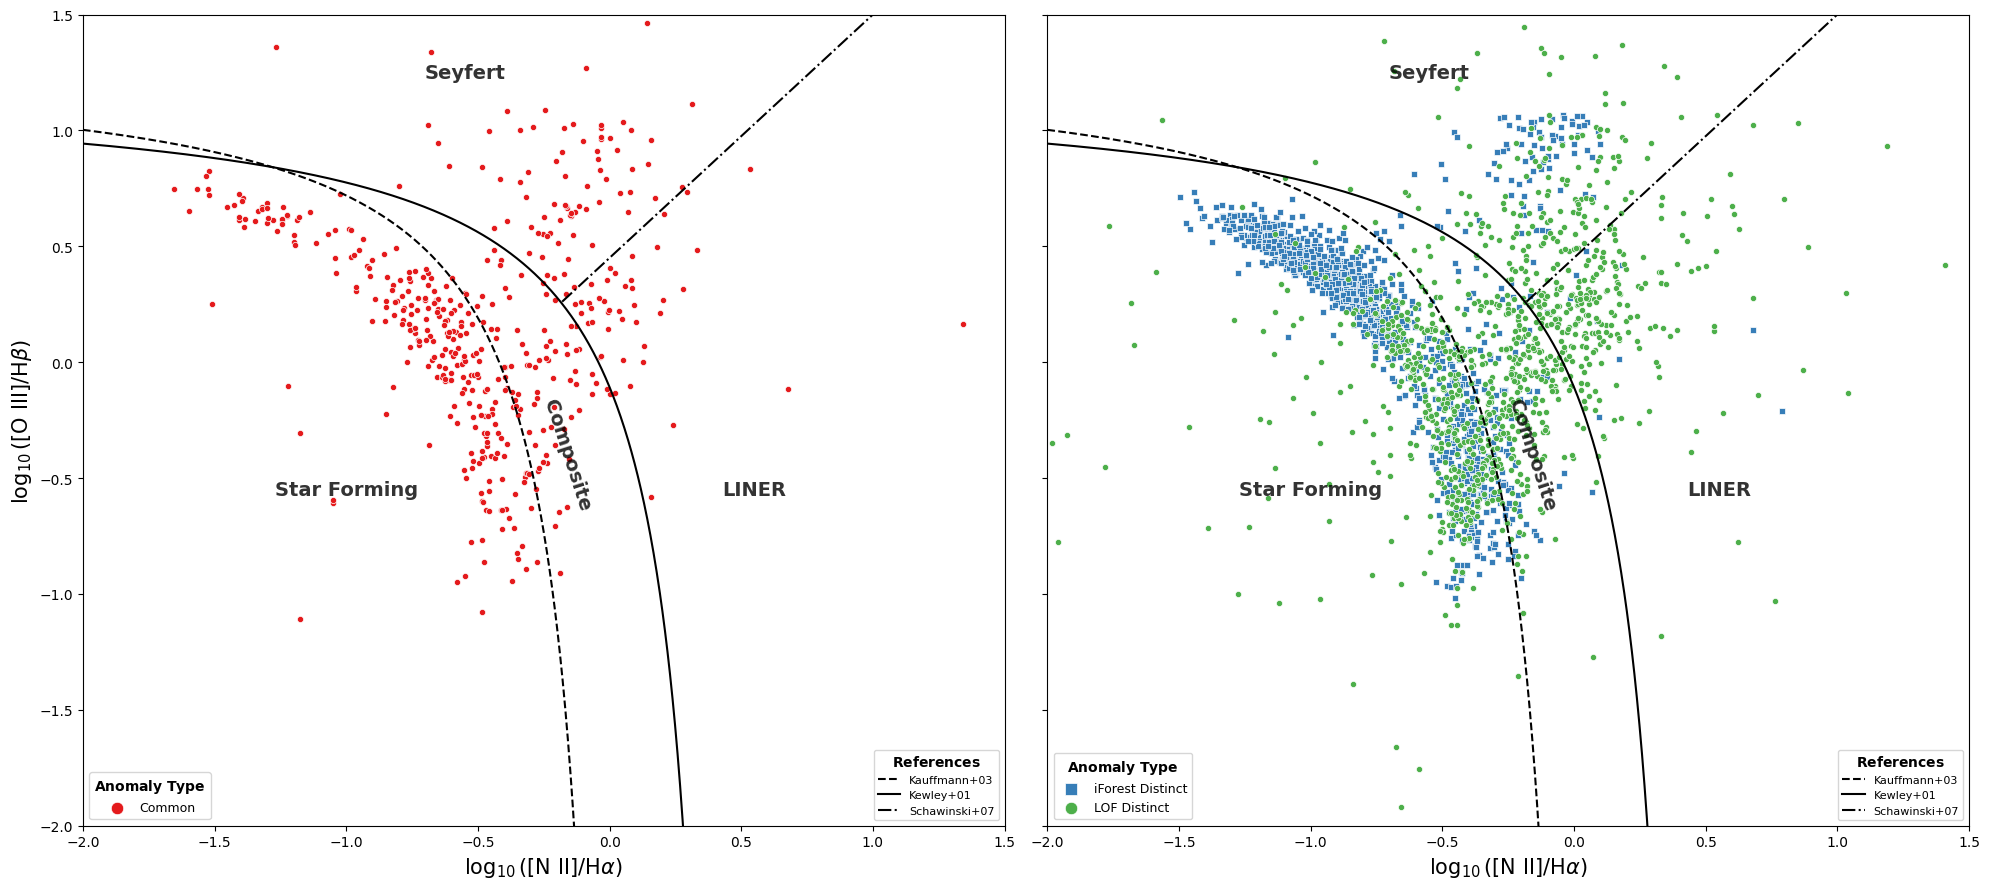

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(20, 9), sharey=True)

# -------------------------------------------------------------
# 1. Plot demarcations (Subtle, so they don't compete with data)
# -------------------------------------------------------------
line_params = {"color": "black", "lw": 1.5, "alpha": 1}  # 'zorder': 5
(lka0,) = axs[0].plot(x_kauff, y_kauff, "--", **line_params, label="Kauffmann+03")
(lke0,) = axs[0].plot(x_kewley, y_kewley, "-", **line_params, label="Kewley+01")
(lschaw0,) = axs[0].plot(x_schaw, y_schaw, "-.", **line_params, label="Schawinski+07")

(lka1,) = axs[1].plot(x_kauff, y_kauff, "--", **line_params, label="Kauffmann+03")
(lke1,) = axs[1].plot(x_kewley, y_kewley, "-", **line_params, label="Kewley+01")
(lschaw1,) = axs[1].plot(x_schaw, y_schaw, "-.", **line_params, label="Schawinski+07")


# -------------------------------------------------------------
# 2. Distinct Anomalies (Color + Shape + Edge)
# -------------------------------------------------------------
# We use 'zorder=5' to make sure these sit on the very top layer
scatter_common = axs[0].scatter(
    log_n2_ha_common,
    log_o3_hb_common,
    color="#e41a1c",
    marker="o",
    s=20,
    edgecolors="white",
    linewidths=0.5,
    label="Common",
    # zorder=5,
)
scatter_iforest = axs[1].scatter(
    log_n2_ha_iforest,
    log_o3_hb_iforest,
    color="#377eb8",
    marker="s",
    s=20,
    edgecolors="white",
    linewidths=0.5,
    label="iForest Distinct",
    # zorder=5
)
scatter_lof = axs[1].scatter(
    log_n2_ha_lof,
    log_o3_hb_lof,
    color="#4daf4a",
    marker="o",
    s=20,
    edgecolors="white",
    linewidths=0.5,
    label="LOF Distinct",
    # zorder=5
)

# -------------------------------------------------------------
# 3. Text and Formatting
# -------------------------------------------------------------
text_style = {"fontsize": 14, "fontweight": "bold", "va": "center", "alpha": 0.8}
axs[0].text(-1.0, -0.55, "Star Forming", ha="center", **text_style)
axs[0].text(-0.16, -0.4, "Composite", ha="center", rotation=-72, **text_style)
axs[0].text(-0.55, 1.25, "Seyfert", ha="center", **text_style)
axs[0].text(0.55, -0.55, "LINER", ha="center", **text_style)

axs[1].text(-1.0, -0.55, "Star Forming", ha="center", **text_style)
axs[1].text(-0.16, -0.4, "Composite", ha="center", rotation=-72, **text_style)
axs[1].text(-0.55, 1.25, "Seyfert", ha="center", **text_style)
axs[1].text(0.55, -0.55, "LINER", ha="center", **text_style)

for ax in axs:
    ax.set_xlim([-2, 1.5])
    ax.set_ylim([-2, 1.5])
    ax.set_xlabel(r"$\log_{10}([\mathrm{N~II}] / \mathrm{H}\alpha)$", fontsize=15)
axs[0].set_ylabel(r"$\log_{10}([\mathrm{O~III}] / \mathrm{H}\beta)$", fontsize=15)

# -------------------------------------------------------------
# 4. Legend with 'markerscale' (Crucial for visibility)
# -------------------------------------------------------------
# Scaling up markers in the legend makes the shapes obvious even if
# the points on the plot are small.
leg_anom = axs[0].legend(
    handles=[scatter_common],
    loc="lower left",
    title=r"$\bf{Anomaly~Type}$",
    fontsize=9,
    frameon=True,
    markerscale=2.0,
)
axs[0].add_artist(leg_anom)

leg_anom = axs[1].legend(
    handles=[scatter_iforest, scatter_lof],
    loc="lower left",
    title=r"$\bf{Anomaly~Type}$",
    fontsize=9,
    frameon=True,
    markerscale=2.0,
)
axs[1].add_artist(leg_anom)


axs[0].legend(
    handles=[lka0, lke0, lschaw0],
    loc="lower right",
    fontsize=8,
    frameon=True,
    title=r"$\bf{References}$",
)

axs[1].legend(
    handles=[lka1, lke1, lschaw1],
    loc="lower right",
    fontsize=8,
    frameon=True,
    title=r"$\bf{References}$",
)

plt.tight_layout()